# Phase 1: Exploratory Data Analysis (EDA)
Before building the TensorFlow pipeline, we need to verify that our curation script successfully balanced the dataset. 

First, we import the necessary libraries for file system navigation, data manipulation, and visualization.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


### Scanning the Processed Directory
Because this notebook is located inside the `notebooks/` folder, we need to step up one level in the directory tree (`../`) to access our newly generated `data/processed/` folder. 

We will loop through every breed folder and count the exact number of images inside.

In [2]:
# Set the path relative to the notebook's location
data_dir = "../data/processed"

# Initialize an empty dictionary to store our counts
breed_counts = {}

# Loop through the directory and count files in each subfolder
for breed in os.listdir(data_dir):
    breed_path = os.path.join(data_dir, breed)
    if os.path.isdir(breed_path):
        # The length of os.listdir() gives us the exact file count
        breed_counts[breed] = len(os.listdir(breed_path))
        
print(f"Successfully counted images for {len(breed_counts)} breeds.")

Successfully counted images for 42 breeds.


### Structuring the Data
Raw dictionaries are hard to plot. We will convert our counts into a structured Pandas `DataFrame`, which acts like a programmatic Excel spreadsheet. Sorting it from highest to lowest will make our final chart much easier to read.

In [3]:
# Convert the dictionary into a 2-column DataFrame
df = pd.DataFrame(list(breed_counts.items()), columns=['Breed', 'Image Count'])

# Sort the data so the longest bars appear at the top of our chart
df = df.sort_values(by='Image Count', ascending=False)

# Display the top 5 rows to verify the structure
df.head()

,Breed,Image Count
4,Bengal,1000
2,American Shorthair,1000
9,Calico,1000
6,Bombay,1000
21,Maine Coon,1000


### Visualizing Class Distribution
To confirm our "Floor" (min 150) and "Ceiling" (max 1000) limits worked perfectly, we will generate a horizontal bar chart. A horizontal layout is best here because trying to cram 42 long breed names along a standard X-axis would make the text unreadable.

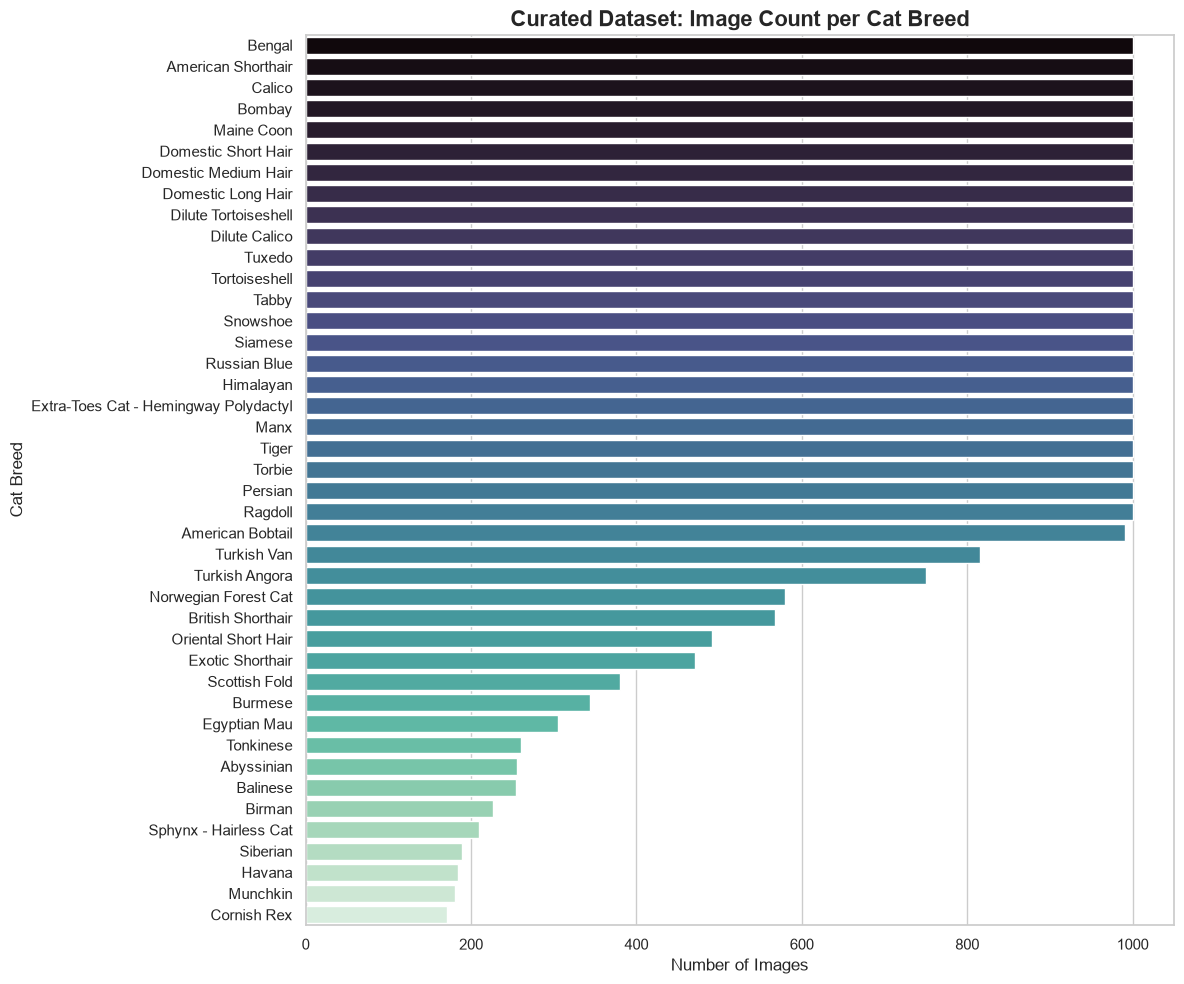

In [4]:
# 1. Configure the canvas size and background style
plt.figure(figsize=(12, 10))
sns.set_theme(style="whitegrid")

# 2. Build the horizontal bar chart
sns.barplot(
    data=df, 
    x='Image Count', 
    y='Breed', 
    hue='Breed',
    legend=False,
    palette='mako' # Uses a sleek, modern color gradient
)

# 3. Add professional labels and titles
plt.title('Curated Dataset: Image Count per Cat Breed', fontsize=16, fontweight='bold')
plt.xlabel('Number of Images', fontsize=12)
plt.ylabel('Cat Breed', fontsize=12)

# 4. Clean up the layout margins and render
plt.tight_layout()
plt.show()